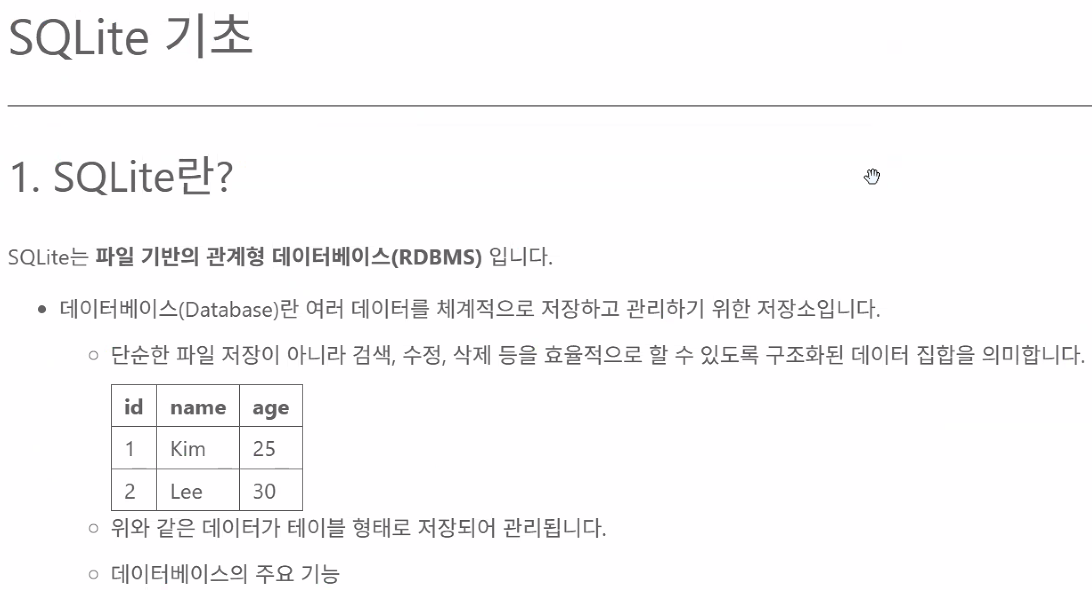

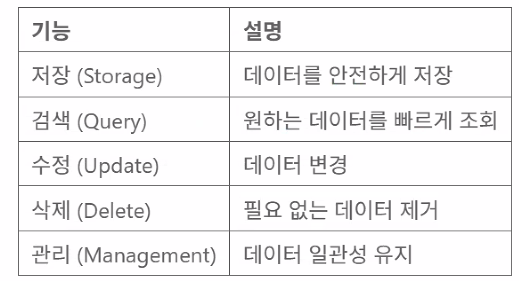

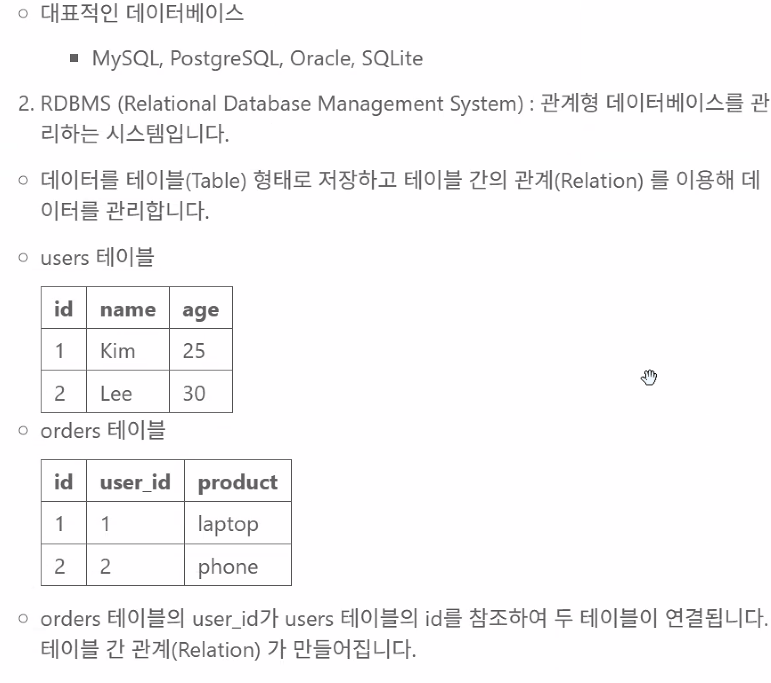

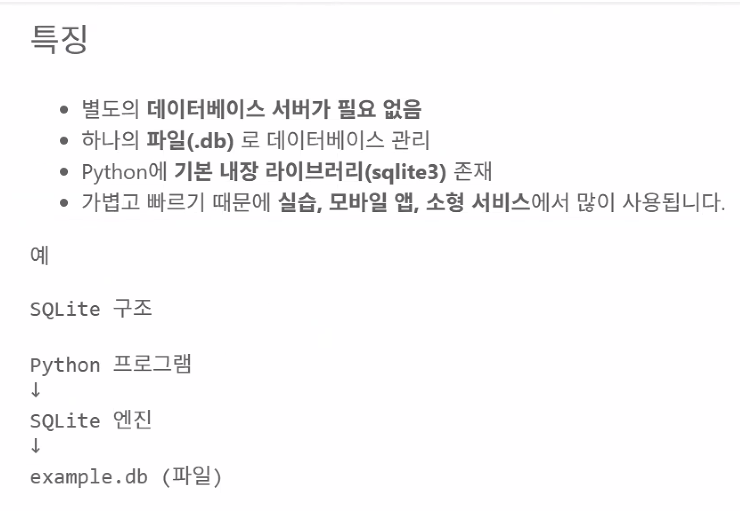

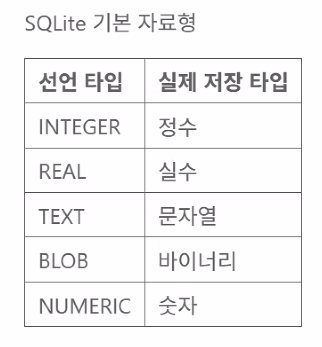

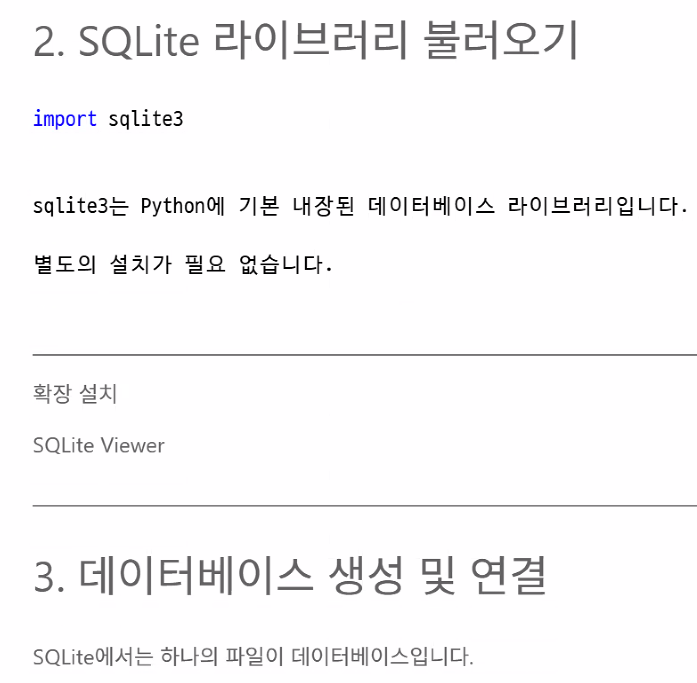

In [2]:
import sqlite3
from pathlib import Path

cwd = Path.cwd()
db_dir = cwd / "db"

if not db_dir.exists():
    db_dir = cwd.parent / "db"

db_dir.mkdir(parents=True, exist_ok=True)
db_path = (db_dir / "example.db").resolve()

conn = sqlite3.connect(db_path)

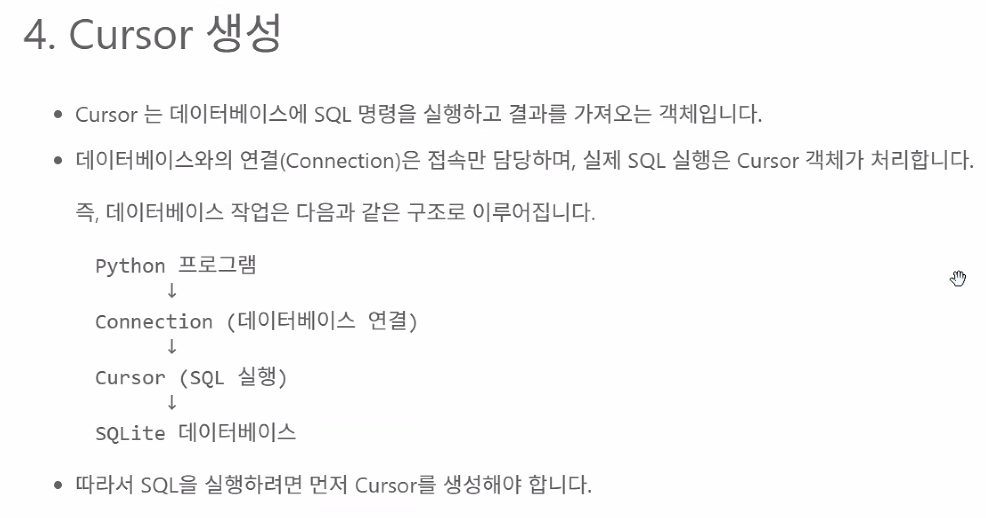

In [3]:
cursor = conn.cursor()

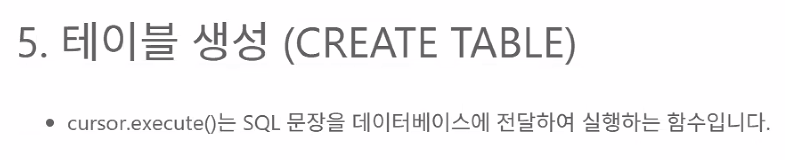

In [4]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY,
    name TEXT,
    age INTEGER
)
""")

# commit() 은 데이터베이스 변경 내용을 실제 파일에 저장하는 명령입니다.
conn.commit()

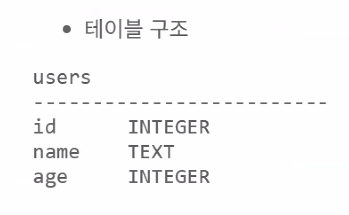

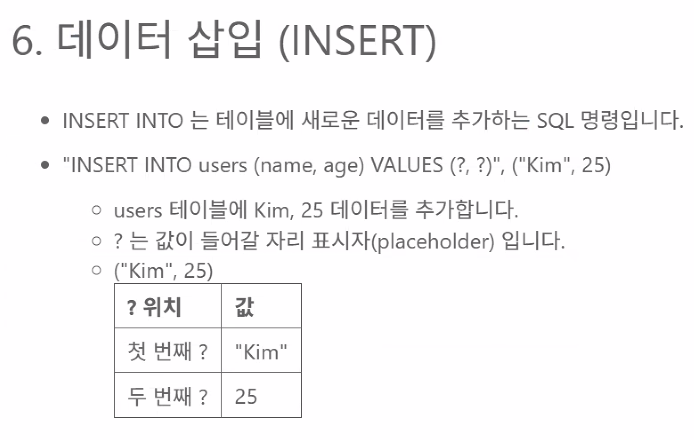

In [5]:
cursor.execute("INSERT INTO users (name, age) VALUES (?, ?)", ("Kim", 25))
cursor.execute("INSERT INTO users (name, age) VALUES (?, ?)", ("Lee", 30))


# commit() 은 데이터베이스 변경 내용을 실제 DB 파일에 저장하는 명령입니다.
conn.commit()

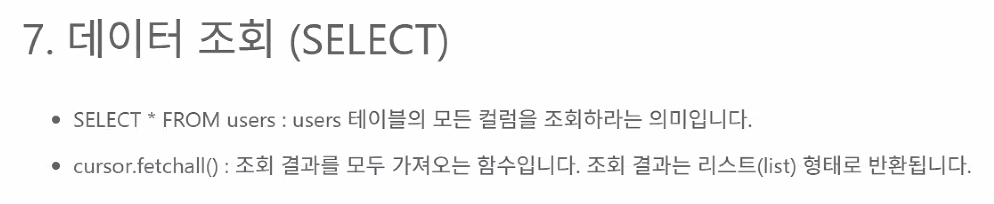

In [6]:
cursor.execute("SELECT * FROM users")

rows = cursor.fetchall()

for row in rows:
    print(row)

(1, 'Kim', 25)
(2, 'Lee', 30)


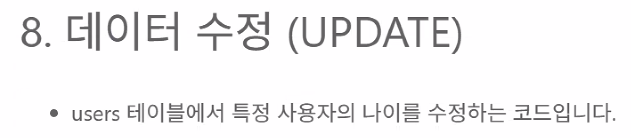

In [7]:
cursor.execute(
    "UPDATE users SET age = ? WHERE name = ?",
    (26, "Kim")
)

conn.commit()

print("데이터 수정 완료")

데이터 수정 완료


In [9]:
cursor.execute("SELECT * FROM users")

rows = cursor.fetchall()

for row in rows:
    print(row)

(1, 'Kim', 26)
(2, 'Lee', 30)


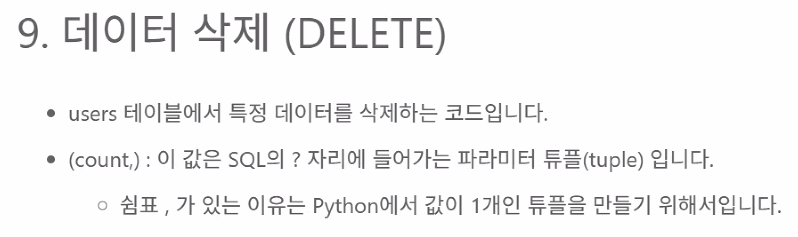

In [10]:
cursor.execute("DELETE FROM users WHERE name = ?", ("Lee",))

conn.commit()

print("데이터 삭제 완료")

데이터 삭제 완료


In [11]:
cursor.execute("SELECT * FROM users")

rows = cursor.fetchall()

for row in rows:
    print(row)

(1, 'Kim', 26)


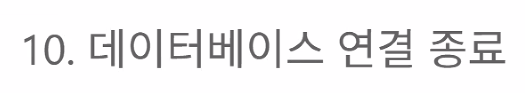

In [12]:
conn.close()

print("데이터베이스 연결 종료")

데이터베이스 연결 종료
